# Imports:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ase.io import Trajectory
from ase.visualize import view
from pymatgen.io.ase import AseAtomsAdaptor
import seaborn as sns
col_list = sns.color_palette("tab10", 100)

import tqdm

from aq_gnome.data_handler import Data_Handler
from aq_gnome import (
    plot_periodic_table_with_values, get_col_dict_for_atoms,
    Stable_Entries, Stability_Criteria, get_simplified_df,
    atoms_from_db, Compound_HHI_scores, sys_in_MP_db,
)

# pHs = np.linspace(-2, 16, 19) # Data specific
# Us = np.linspace(-2, 4, 31) # Data specific

# Database setup:

In [2]:
# Define directory of data (can be left as None if the data folder is in
# the package root):
dir_of_data = None

dh = Data_Handler(
# Whether to apply solid filter:
    solid_filter = True,
# Whether to use only GGA calculations (True), or include r2SCAN data via the MP-mixing scheme (False):
    gga_only = False,
# Path to data directory:
    path_to_data_directory = dir_of_data
    )

In [3]:
compounds_df = dh.get_df()
compounds_df.columns

Index(['Composition', 'MaterialId', 'Reduced Formula', 'Elements', 'NSites',
       'Volume', 'Density', 'Point Group', 'Space Group', 'Space Group Number',
       'Crystal System', 'Uncorrected Energy', 'Corrected Energy',
       'Formation Energy Per Atom', 'Decomposition Energy Per Atom',
       'Dimensionality Cheon', 'Bandgap', 'Is Train',
       'Decomposition Energy Per Atom All',
       'Decomposition Energy Per Atom Relative',
       'Decomposition Energy Per Atom MP',
       'Decomposition Energy Per Atom MP OQMD', 'Data Directory',
       'gga_only_pbx_save_id', 'mixed_pbx_save_id', 'Disorder Probability',
       'average_HHI_P', 'average_HHI_R', 'average_HHI_P_excluding_O_H',
       'average_HHI_R_excluding_O_H', 'max_HHI_P', 'max_HHI_R'],
      dtype='object')

# Inclusion/exclusion of elements:

In [ ]:
radioactive_elements = ['Tc',  'Ra', 'Rf', 'Db', 'Sg', 'Bh', 'Hs',
                        'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv',
                        'Ts', 'Og', 'Pm', 'Ac', 'Th', 'Pa', 'U', 'Np',
                        'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md',
                        'No', 'Lr', 'Po', 'At', 'Rn'
                        ]

reactive_with_water_elements = ['Li', 'Na', 'K', 'Rb', 'Cs', 'Fr', 'Ca', 'Ba']

toxic_elements = ['Tl', 'Pb', 'As', 'Cd', 'Hg']

too_rare_elements = ['Be', 'Y', 'Nb', 'Rh', 'Pd', 'Te', 'Sb', 'Lu', 'Re',
                    'Os', 'Pt', 'Hg', 'Bi', 'La', 'Ce', 'Pr', 'Nd', 'Pm',
                    'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
                    'Ru', 'Ir']


CMR = [
    'Be', 'B', 'Si', 'Sc', 'Ti', 'V', 'Co', 'Ga', 'Ge', 'Cr', 'Y', 'Nb',
    'Ru', 'Rh', 'Pd', 'Sb', 'Lu', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt', 'Bi',
    'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd',
    'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb'
]

platinum_group = ['Ru', 'Rh', 'Pd', 'Os', 'Ir', 'Pt']


elements_to_exclude = radioactive_elements + toxic_elements + reactive_with_water_elements + ['Br', 'C', 'F', 'Se', 'Te', 'B', 'P', 'S', 'Cl'] # + ['S', 'C', 'Cl', 'P', 'B', 'Bi']
 # + higly_concentrated_elements  # elements to discart
elements_whic_must_be_included = ['O']

plot_periodic_table_with_values(
    get_col_dict_for_atoms(elements_to_discard=elements_to_exclude,
                           elements_to_include=elements_whic_must_be_included)
)

### Discarding materials based on element selection

In [5]:
dh.restore_df()
dh.remove_entries_with_elements(elements_to_exclude)
dh.remove_entries_without_elements(elements_whic_must_be_included, False)
# dh.remove_entries_without_elements(['Li', 'Na', 'K'], False)

Number of entries removed: 289367 Number of entries left: 239604 which is 45.30% of total GNoME database
Removed all entries not containing any of the following elements: O .Number of entries removed: 220140 Number of entries left: 19464 which is 3.68% of total GNoME database


### pbx stability criteria

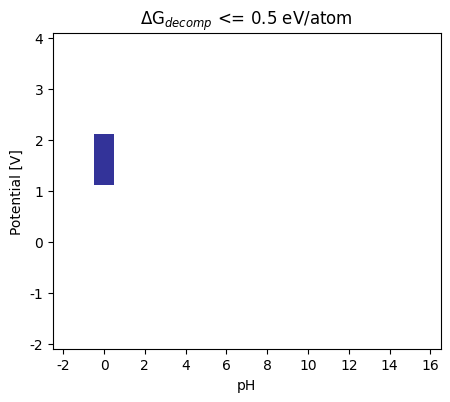

In [6]:
SCS = [
    Stability_Criteria(pHs=[0], Us=[1.2, 2], decomposition_threshold=0.5),
    # Stability_Criteria(pHs=[7], Us=[-0.4, -2], decomposition_threshold=0.2),
       # Stability_Criteria(pHs=0, Us=[1.2, 1.6], decomposition_threshold=0.05),
       # Stability_Criteria(pHs=[2, 5], Us=[0., 2], decomposition_threshold=1),
       ]

for sc in SCS:
    sc.visualize()

In [7]:
se = Stable_Entries(dh, SCS)
se.get_stable_df()

Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


100%|██████████| 19464/19464 [00:20<00:00, 937.57it/s] 


Found 11606 stable entries given the stability criteria.


,"max_dG_U[1.2,2]_pH0",Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,Space Group,...,Data Directory,gga_only_pbx_save_id,mixed_pbx_save_id,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
25,0.494255,Dy5Ho1Mo1O12,0003926385,Dy5HoMoO12,"[O, Mo, Dy, Ho]",19,261.1871,8.0448,1,P1,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_0003926385,GGA_0003926385,0.997482,3442.0,1574.0,8486.0,3414.0,9500.0,5300.0
143,0.252531,Lu3O24Tm1W4Y4,0011925c0a,Y4TmLu3(WO6)4,"[O, Y, Tm, Lu, W]",36,453.4655,7.9419,1,P1,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_0011925c0a,GGA_0011925c0a,0.910963,3256.0,1444.0,8767.0,3333.0,9800.0,4300.0
152,0.244767,Dy2O24Tb6W4,00131f61c3,Tb3Dy(WO6)2,"[O, Tb, Dy, W]",36,467.0223,8.5259,m,Pc,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_00131f61c3,GGA_00131f61c3,0.935917,3222.0,1500.0,8667.0,3500.0,9500.0,4300.0
210,0.160114,Ag2O14Pt4Sr2,001903554b,SrAgPt2O7,"[O, Sr, Ag, Pt]",22,279.9641,8.2759,mmm,Imma,...,gs://surface-design/input/round_6_4/1e_3_med_0...,GGA_001903554b,GGA_001903554b,0.208667,1809.0,2373.0,4100.0,5650.0,5500.0,9100.0
216,0.334610,Dy1Ho4O14Sb2Sm1,001a6fb094,SmDyHo4(SbO7)2,"[O, Sb, Sm, Dy, Ho]",22,297.4011,8.0408,2/m,C2/m,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_001a6fb094,GGA_001a6fb094,0.985978,3627.0,1473.0,9100.0,3175.0,9500.0,3400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528810,0.129168,Mg2Mo6O24Zn4,ffe948382b,MgZn2(MoO4)3,"[O, Mg, Zn, Mo]",36,547.6919,3.8501,-1,P-1,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_ffe948382b,Not computed,0.405052,1206.0,1456.0,2617.0,3367.0,5300.0,5300.0
528828,0.264954,Co4Fe4Ho1Lu3O20,ffeba8423a,HoLu3Fe4(CoO5)4,"[O, Fe, Co, Ho, Lu]",32,348.7297,6.9946,m,Pm,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_ffeba8423a,GGA_ffeba8423a,0.946479,2188.0,1212.0,5000.0,2400.0,9500.0,3100.0
528842,0.243181,Dy1Lu4O24W4Y3,ffed6650f2,DyY3Lu4(WO6)4,"[O, Y, Dy, Lu, W]",36,451.7325,8.2651,2,P2,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_ffed6650f2,GGA_ffed6650f2,0.949361,3247.0,1458.0,8742.0,3375.0,9800.0,4300.0
528862,0.470533,Au2Dy5O14Y1,fff02e5727,Dy5Y(AuO7)2,"[O, Y, Dy, Au]",22,297.6143,8.4771,2/m,C2/m,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_fff02e5727,GGA_fff02e5727,0.983418,3023.0,1232.0,7438.0,2512.0,9800.0,3100.0


In [ ]:
# df = df[df["Disorder Probability"] < 0.2]
# df = df[~df['Reduced Formula'].apply(lambda x: '(SO4)' in x)]

# df = df[~df['Elements'].apply(lambda x: 'F' in x)]

df = se.get_stable_df().copy()

# df = df[df['Elements'].apply(lambda x: any([el in x for el in ['Cn']]))]
# df = df[df['Elements'].apply(lambda x: any([el in x for el in ['Pd']]))]


df = df[df['Dimensionality Cheon'] == '3D']
# df = df[df['NSites'] < 40]

# df = df[df['Elements'].apply(lambda x: len(x) <= 4)]

df = df[df['Bandgap'] < 0.05]
# df = df[df['average_HHI_P_excluding_OHCNPS'] < 6000]
# df = df[df['average_HHI_R_excluding_OHCNPS'] < 6000]
# # df = df[df['max_HHI_P'] < 6000]
# df = df[df['max_HHI_R'] < 6000]
df = df[df['Disorder Probability'] < 0.2]

# df = get_simplified_df(df)
# df = df.sort_values(by="Bandgap")
# df = df.sort_values(by="HHI_P_excluding_OHCNP")
print(len(df))

df = df.sort_values(by="Bandgap")
get_simplified_df(df)


In [ ]:
simp = sys_in_MP_db('YOUR_MATERIALS_PROJECT_API_KEY')

df = df[~df['Elements'].apply(lambda x: simp.in_db(x))]
print(len(df))
get_simplified_df(df)

In [ ]:
temp_df = df.copy()

temp_df = temp_df[temp_df['Elements'].apply(lambda x: any([el in x for el in ['Pt']]))]
temp_df = temp_df[temp_df['Elements'].apply(lambda x: any([el in x for el in ['Pd']]))]

temp_df

In [ ]:
get_simplified_df(df.sort_values(by="Disorder Probability"))

In [ ]:
retrive_atoms = atoms_from_db()

view(
retrive_atoms.get_atoms_objects_from_df(df.sort_values(by="average_HHI_P_excluding_OHCNPS"))
)

In [ ]:
df.sort_values(by="average_HHI_P_excluding_OHCNPS")